# Predicting Mortgage Denials from Public HMDA Data
**DTSC 2301 - Personal Portfolio Project Two**

## Introduction
For most households, buying a home is the largest financial decision they will make, and a mortgage denial can delay or end that plan. Under the Home Mortgage Disclosure Act (HMDA), most U.S. mortgage lenders must report loan-level data on the applications they receive, including the final decision. The Consumer Financial Protection Bureau (CFPB) publishes this data, which makes HMDA one of the few large, public sources of real lending outcomes.

Public HMDA data leaves out important underwriting information, most notably **applicant credit scores**. Lenders see far more than the public does. This project does not try to recreate a lender's full decision process. It measures **how much of the outcome can be explained using only publicly reported application characteristics**, and whether the model's errors fall evenly across demographic groups.

## Research Question
> Using only the application characteristics lenders publicly report under HMDA, how accurately can we predict whether a conventional, owner-occupied home-purchase mortgage application in North Carolina is denied rather than approved?

### Sub-questions
1. Which financial features (debt-to-income ratio, loan-to-value ratio, income, loan amount) contribute most to predicted denial?
2. Do the model's error rates differ across applicant race, ethnicity, or sex groups, even though those fields are excluded as model inputs?


## Problem Setup
| | |
|---|---|
| **Task** | Binary classification |
| **Target** | `denied`: 1 = application denied (`action_taken` = 3); 0 = approved (`action_taken` = 1 or 2) |
| **Population** | Conventional, owner-occupied, home-purchase applications in North Carolina, 2025 |
| **Excluded** | Withdrawn and incomplete applications, purchased loans, and preapproval requests, since none reflect a completed lending decision on an application |

## Who This Is For
The intended audience is **fair-lending researchers, housing analysts, and regulators** who study patterns in lending outcomes. The model is **not** meant for individual applicants to predict their own approval, because it cannot account for credit history.

## A Note on Interpretation
The findings are **associations, not causal effects**. Race, ethnicity, and sex are left out of the model and used only to audit its errors. Differences in error rates across groups can point to areas for further study, but they cannot on their own establish discrimination by lenders, because key underwriting variables are missing.

## Related Work
Prior research has used Home Mortgage Disclosure Act data to model mortgage approval and denial decisions and to evaluate whether predictive models operate equitably across demographic groups. Zou and Khern-am-nuai (2023) found that machine-learning models trained on historical mortgage decisions may reproduce or amplify existing disparities, emphasizing the risks of using automated recommendations without careful fairness evaluation. Similarly, Babaei et al. (2026) used HMDA data and explainable machine-learning methods to examine differences in loan-approval outcomes and model behavior across racial groups.

However, mortgage-denial models based only on public HMDA variables have important limits. Using confidential HMDA data that adds credit scores and automated-underwriting recommendations to the publicly reported variables, Bhutta et al. (2025) showed that observable applicant risk factors, including credit scores, debt-to-income ratios, loan-to-value ratios, and underwriting-system results, explain most of the racial differences in denial rates. Public HMDA data includes debt-to-income and loan-to-value ratios but not credit scores or underwriting-system results. Therefore, this project treats model predictions and group-level error differences as associations in publicly reported data rather than proof of lender discrimination.

### References
- Babaei, G., Giudici, P., & Wu, L. (2026). Explainable fairness in mortgage lending. In R. Guidotti, U. Schmid, & L. Longo (Eds.), *Explainable artificial intelligence: Third World Conference, xAI 2025, Istanbul, Turkey, July 9–11, 2025, proceedings, Part IV* (pp. 378–398). Springer. https://doi.org/10.1007/978-3-032-08330-2_18
- Bhutta, N., Hizmo, A., & Ringo, D. (2025). How much does racial bias affect mortgage lending? Evidence from human and algorithmic credit decisions. *The Journal of Finance, 80*(3), 1463–1496. https://doi.org/10.1111/jofi.13444
- Zou, L., & Khern-am-nuai, W. (2023). AI and housing discrimination: The case of mortgage applications. *AI and Ethics, 3*(4), 1271–1281. https://doi.org/10.1007/s43681-022-00234-9

## Data Description
- **Source:** 2025 HMDA loan/application register for North Carolina, downloaded from the FFIEC HMDA Data Browser (Federal Financial Institutions Examination Council, n.d.). Field definitions come from the official HMDA data-field documentation.
    - https://ffiec.cfpb.gov/documentation/publications/loan-level-datasets/lar-data-fields#action_taken
- **Unit of analysis:** each row is **one mortgage application** submitted to a reporting lender in 2025.
- **Size:** 552,230 applications and 99 columns in the raw file. After scoping to the research question, 98,352 applications remain, and 95,270 after cleaning.
- **Target:** `denied` (1 = denied, 0 = approved), built from `action_taken`.
- **Available features:** loan characteristics (amount, term, LTV, property value), applicant financials (income, DTI), property type, applicant age, and demographic fields (used for the fairness audit only).
- **Collection limits:** HMDA does not cover every lender (small institutions below reporting thresholds are exempt), some lenders report certain fields as `"Exempt"`, and public HMDA leaves out credit scores.

# **AI Transparency**

I used AI to write the code of the visualizations to save time on that end, and also used it help me find and fix bugs in my data analysis and cleaning code cells. However all the decisions pertaining towards which charts and graphs I wanted and the data cleaning decisions alongside the explanation as to why behind was driven by me.

In addition, I used AI to clean up the messy notebook and turned it into an notebook that looks good for presentation and made it easy to read and follow from top to bottom.

# Part 1: Data Loading & Scope

In [41]:
# Loading Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [42]:
# Loading only the columns I need, data understanding was done with this website:
# https://ffiec.cfpb.gov/documentation/publications/loan-level-datasets/lar-data-fields#action_taken

cols = [
    "lei", "derived_loan_product_type", "derived_dwelling_category",
    "action_taken", "preapproval", "loan_purpose",
    "business_or_commercial_purpose", "loan_amount", "loan_to_value_ratio",
    "interest_rate",
    "loan_term", "property_value", "construction_method", "occupancy_type",
    "applicant_age", "income", "debt_to_income_ratio",
    "applicant_ethnicity-1", "applicant_race-1", "applicant_sex",
]

df_raw = pd.read_csv("NC_Mortgate Loan Data.csv", usecols=cols, low_memory=False)

all_columns = pd.read_csv("NC_Mortgate Loan Data.csv", nrows=0).columns   # header only
print("Columns in raw file:", len(all_columns))
print("Raw applications:", f"{len(df_raw):,}")
df_raw.head(15)

Columns in raw file: 99
Raw applications: 552,230


,lei,derived_loan_product_type,derived_dwelling_category,action_taken,preapproval,loan_purpose,business_or_commercial_purpose,loan_amount,loan_to_value_ratio,interest_rate,loan_term,property_value,construction_method,occupancy_type,income,debt_to_income_ratio,applicant_ethnicity-1,applicant_race-1,applicant_sex,applicant_age
0,7H6GLXDRUGQFU57RNE97,Conventional:First Lien,Single Family (1-4 Units):Site-Built,6,2,32,1,175000.0,NaN,6.625,360,235000,1,3,NaN,NaN,4.0,7.0,4,8888
1,7H6GLXDRUGQFU57RNE97,Conventional:First Lien,Single Family (1-4 Units):Site-Built,6,2,31,1,165000.0,NaN,6.375,360,235000,1,3,NaN,NaN,4.0,7.0,4,8888
2,7H6GLXDRUGQFU57RNE97,FHA:First Lien,Single Family (1-4 Units):Site-Built,6,2,1,2,145000.0,NaN,5.5,360,165000,1,1,NaN,NaN,4.0,7.0,4,8888
3,7H6GLXDRUGQFU57RNE97,Conventional:First Lien,Single Family (1-4 Units):Site-Built,6,2,32,1,165000.0,NaN,6.625,360,235000,1,3,NaN,NaN,4.0,7.0,4,8888
4,7H6GLXDRUGQFU57RNE97,FHA:First Lien,Single Family (1-4 Units):Site-Built,6,2,1,2,125000.0,NaN,6.75,360,135000,1,1,NaN,NaN,4.0,7.0,4,8888
5,7H6GLXDRUGQFU57RNE97,FHA:First Lien,Single Family (1-4 Units):Manufactured,6,2,4,2,115000.0,NaN,3.5,360,175000,2,1,NaN,NaN,4.0,7.0,4,8888
6,7H6GLXDRUGQFU57RNE97,FHA:First Lien,Single Family (1-4 Units):Site-Built,6,2,1,2,255000.0,NaN,8,360,265000,1,1,NaN,NaN,4.0,7.0,4,8888
7,7H6GLXDRUGQFU57RNE97,FHA:First Lien,Single Family (1-4 Units):Site-Built,6,2,1,2,145000.0,NaN,3.75,360,165000,1,1,NaN,NaN,4.0,7.0,4,8888
8,7H6GLXDRUGQFU57RNE97,FHA:First Lien,Single Family (1-4 Units):Site-Built,6,2,1,2,145000.0,NaN,3,360,165000,1,1,NaN,NaN,4.0,7.0,4,8888
9,7H6GLXDRUGQFU57RNE97,FHA:First Lien,Single Family (1-4 Units):Site-Built,6,2,5,2,115000.0,NaN,5.5,670,135000,1,1,NaN,NaN,4.0,7.0,4,8888


In [43]:
# Scope to the research question

df = df_raw[
    df_raw["action_taken"].isin([1, 2, 3])                               # decided applications only
    & (df_raw["loan_purpose"] == 1)                                      # home purchase
    & (df_raw["occupancy_type"] == 1)                                    # owner-occupied
    & (df_raw["derived_loan_product_type"] == "Conventional:First Lien") # conventional, first lien
    & (df_raw["business_or_commercial_purpose"] == 2)                    # not a business loan
].copy()

# Target: 1 = denied, 0 = approved
df["denied"] = (df["action_taken"] == 3).astype(int)

print(df.shape)
print("Denial rate:", round(df["denied"].mean(), 3))
df.head(15)

(98352, 21)
Denial rate: 0.157


,lei,derived_loan_product_type,derived_dwelling_category,action_taken,preapproval,loan_purpose,business_or_commercial_purpose,loan_amount,loan_to_value_ratio,interest_rate,...,property_value,construction_method,occupancy_type,income,debt_to_income_ratio,applicant_ethnicity-1,applicant_race-1,applicant_sex,applicant_age,denied
46,7H6GLXDRUGQFU57RNE97,Conventional:First Lien,Single Family (1-4 Units):Site-Built,1,2,1,2,175000.0,NaN,3.49,...,365000,1,1,94.0,30%-<36%,2.0,5.0,2,25-34,0
47,7H6GLXDRUGQFU57RNE97,Conventional:First Lien,Single Family (1-4 Units):Site-Built,1,2,1,2,325000.0,NaN,2,...,555000,1,1,190.0,20%-<30%,2.0,5.0,2,25-34,0
49,7H6GLXDRUGQFU57RNE97,Conventional:First Lien,Single Family (1-4 Units):Site-Built,1,2,1,2,145000.0,NaN,4.875,...,265000,1,1,55.0,41,3.0,5.0,2,>74,0
51,7H6GLXDRUGQFU57RNE97,Conventional:First Lien,Single Family (1-4 Units):Site-Built,3,2,1,2,45000.0,NaN,NaN,...,105000,1,1,96.0,NaN,2.0,5.0,1,35-44,1
52,7H6GLXDRUGQFU57RNE97,Conventional:First Lien,Single Family (1-4 Units):Site-Built,1,2,1,2,205000.0,NaN,2.375,...,275000,1,1,67.0,30%-<36%,2.0,5.0,2,35-44,0
53,7H6GLXDRUGQFU57RNE97,Conventional:First Lien,Single Family (1-4 Units):Site-Built,1,2,1,2,245000.0,NaN,5,...,415000,1,1,140.0,20%-<30%,2.0,2.0,2,45-54,0
55,7H6GLXDRUGQFU57RNE97,Conventional:First Lien,Single Family (1-4 Units):Site-Built,3,2,1,2,95000.0,NaN,NaN,...,125000,1,1,54.0,NaN,3.0,6.0,1,25-34,1
56,7H6GLXDRUGQFU57RNE97,Conventional:First Lien,Single Family (1-4 Units):Site-Built,1,2,1,2,155000.0,NaN,2.625,...,NaN,1,1,82.0,30%-<36%,2.0,5.0,2,35-44,0
58,7H6GLXDRUGQFU57RNE97,Conventional:First Lien,Single Family (1-4 Units):Site-Built,3,2,1,2,155000.0,NaN,NaN,...,235000,1,1,24.0,>60%,3.0,5.0,2,65-74,1
63,7H6GLXDRUGQFU57RNE97,Conventional:First Lien,Single Family (1-4 Units):Site-Built,3,2,1,2,155000.0,NaN,NaN,...,NaN,1,1,0.0,<20%,2.0,5.0,1,25-34,1


## Variable Selection

The raw 2025 North Carolina HMDA file contains **99 columns**. After filtering to the research population (decided, conventional first-lien, owner-occupied, home-purchase, non-business applications), **98,352 applications** remain, with a **15.7% denial rate**. I kept 20 columns. Each one had to pass a single test: **would this information be known at the time of application, before the lender's decision?** Any variable recorded *because of* the decision would leak the answer into the model.

### Variables Kept

**Target source**
| Variable | Role |
|---|---|
| `action_taken` | Used to build the target `denied` (3 = denied; 1, 2 = approved), then dropped as a feature |

**Financial features (core predictors)**
| Variable | Why it matters |
|---|---|
| `debt_to_income_ratio` | One of the most important underwriting criteria: can the applicant afford the monthly payment? |
| `loan_to_value_ratio` | Measures the lender's risk if the borrower defaults. A higher LTV means a smaller down payment and less equity. |
| `income` | The applicant's capacity to repay |
| `loan_amount` | Size of the credit risk the lender takes on |
| `property_value` | Collateral backing the loan |
| `loan_term` | Loan length. Nonstandard terms may carry different risk. |

**Application and property characteristics**
| Variable | Why it matters |
|---|---|
| `preapproval` | Whether the application began with a preapproval request. *Later removed as a feature after the leakage check in Part 3.* |
| `derived_dwelling_category`, `construction_method` | Site-built vs. manufactured housing. Manufactured homes are underwritten differently and historically see higher denial rates. |
| `applicant_age` | Reported in age bands. Included as an applicant characteristic. |

**Scope-filter variables** (used to define the population, then dropped because each has only one value after filtering)
`derived_loan_product_type`, `loan_purpose`, `occupancy_type`, `business_or_commercial_purpose`

**Audit-only variables** (never used as model inputs)
| Variable | Use |
|---|---|
| `applicant_race-1`, `applicant_ethnicity-1`, `applicant_sex` | Excluded from training. Used only to compare model error rates across groups (Sub-question 2). |
| `lei` | Lender identifier. Used for EDA and grouping, not as a feature, because it would mostly teach the model which lenders deny often rather than which applications are risky. |

**Kept for EDA only**
| Variable | Why it's not a feature |
|---|---|
| `interest_rate` | Only exists for loans that were approved. As the check below shows, it is missing for every denied application, so it would reveal the outcome directly. |

### Notable Variables Dropped

**Post-decision fields (target leakage)**
| Variable | Reason |
|---|---|
| `denial_reason-1` to `-4` | Only filled in when an application is denied |
| `rate_spread`, `total_loan_costs`, `origination_charges`, `discount_points`, `lender_credits`, `total_points_and_fees` | Pricing and cost fields that exist only for originated loans |
| `purchaser_type` | Describes who bought the loan after origination |
| `hoepa_status` | Determined from the terms of an originated loan |

**Missing or unusable credit information**
| Variable | Reason |
|---|---|
| `applicant_credit_score_type` | Reports only *which scoring model* was used, not the score itself. HMDA does not publish credit scores, which is this project's central limitation. |
| `aus-1` to `-5` | Identifies the automated underwriting system used, not its result. "Not applicable" codes may be tied to how far an application progressed, which risks indirect leakage. |

**Redundant or out of scope**
| Variable | Reason |
|---|---|
| `derived_race`, `derived_ethnicity`, `derived_sex` | Combine applicant and co-applicant into one label. The applicant-level fields were kept instead for a cleaner audit. |
| `loan_type`, `lien_status` | Already captured by `derived_loan_product_type` |
| Co-applicant fields (race, sex, age, credit score type) | Kept the scope to the primary applicant. Many applications have no co-applicant. |
| `reverse_mortgage`, `open-end_line_of_credit`, `balloon_payment`, `interest_only_payment`, `negative_amortization` | Describe specialty loan products that are not relevant to standard home-purchase mortgages |
| Census tract fields (`tract_minority_population_percent`, `tract_to_msa_income_percentage`, etc.) | Describe the neighborhood rather than the applicant. `tract_minority_population_percent` in particular acts as a proxy for race, which would undermine the choice to exclude race as a model input. |
| `county_code`, `census_tract`, `derived_msa-md` | High-cardinality geographic identifiers that raise the same proxy concern |

Checking the claim above: if `interest_rate` is missing for every denied application (`denied` = 1) and almost never for approved ones, it reveals the outcome and cannot be a feature.

In [44]:
# Verifying the interest_rate leak: is it missing more often for denied applications?
df.groupby("denied")["interest_rate"].apply(lambda s: s.isna().mean()).rename("Share missing").to_frame().style.format("{:.1%}")

,Share missing
denied,
0,0.0%
1,100.0%


# Part 2: Data Cleaning

### Step 1: How much data is missing?

In [45]:
# Checking for missing data
features = ["debt_to_income_ratio", "loan_to_value_ratio", "income", "loan_amount",
            "property_value", "loan_term", "preapproval",
            "derived_dwelling_category", "construction_method", "applicant_age"]

missing = pd.DataFrame({
    "Missing count": df[features].isna().sum(),
    "Missing %": df[features].isna().mean() * 100
}).sort_values("Missing %", ascending=False)

missing.style.format({"Missing %": "{:.2f}%", "Missing count": "{:,}"}) \
       .bar(subset=["Missing %"], color="#302992") \
       .set_caption("Percentage of Missing Data by Feature")


,Missing count,Missing %
loan_to_value_ratio,"12,353",12.56%
income,"1,128",1.15%
property_value,918,0.93%
debt_to_income_ratio,823,0.84%
loan_term,367,0.37%
loan_amount,0,0.00%
preapproval,0,0.00%
derived_dwelling_category,0,0.00%
construction_method,0,0.00%
applicant_age,0,0.00%


### Step 2: Is the missing data random, or tied to the outcome?
I don't want to drop rows based on the missing percentages alone. Next I check whether rows with missing values are approved or denied at different rates.

*AI transparency: I used AI to write the code for the visualization below.*

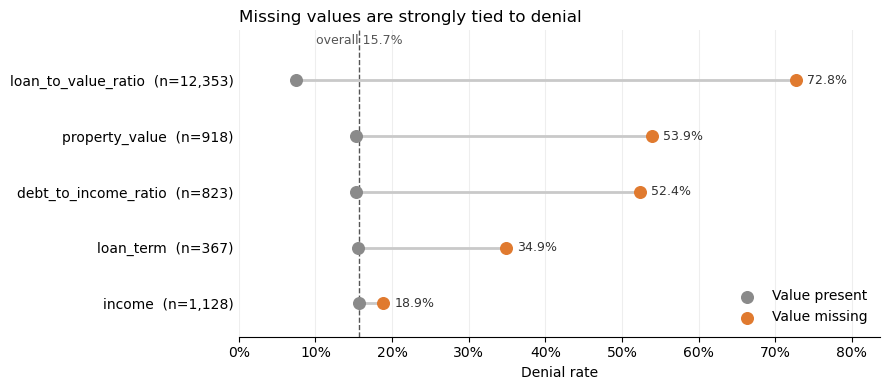

,Missing count,Denial rate if missing,Denial rate if present
loan_to_value_ratio,"12,353",72.8%,7.5%
property_value,918,53.9%,15.3%
debt_to_income_ratio,823,52.4%,15.4%
loan_term,367,34.9%,15.6%
income,"1,128",18.9%,15.6%


Rows lost with dropna():   14,214 (14.5% of data)
Denials lost:              9,432 of 15,415 (61.2%)
Denial rate after dropna(): 15.7% -> 7.1%


In [46]:
# Checking if missing data random, or if its tied to the outcome
check_cols = ["loan_to_value_ratio", "property_value", "debt_to_income_ratio", "loan_term", "income"]
overall_rate = df["denied"].mean()

miss_vs_target = pd.DataFrame({
    "Missing count": df[check_cols].isna().sum(),
    "Denial rate if missing": [df.loc[df[c].isna(), "denied"].mean() for c in check_cols],
    "Denial rate if present": [df.loc[df[c].notna(), "denied"].mean() for c in check_cols],
}, index=check_cols).sort_values("Denial rate if missing")  # ascending -> largest ends up on top

# Dumbbell chart: present vs. missing denial rate per column
fig, ax = plt.subplots(figsize=(9, 4))
y = range(len(miss_vs_target))
present = miss_vs_target["Denial rate if present"]
missing = miss_vs_target["Denial rate if missing"]

ax.hlines(y, present, missing, color="#c9c9c9", lw=2, zorder=1)
ax.scatter(present, y, s=70, color="#8a8a8a", label="Value present", zorder=2)
ax.scatter(missing, y, s=70, color="#e07a2f", label="Value missing", zorder=2)
ax.axvline(overall_rate, color="#555", ls="--", lw=1, zorder=0)
ax.text(overall_rate, len(miss_vs_target) - 0.4, f"overall {overall_rate:.1%}",
        ha="center", va="bottom", fontsize=9, color="#555")

# Label only the "missing" end, offset so the text never sits on the marker
for yi, m in zip(y, missing):
    ax.annotate(f"{m:.1%}", (m, yi), xytext=(8, 0), textcoords="offset points",
                va="center", fontsize=9, color="#333")

# Put the missing count in the y-tick labels instead of a separate column
ax.set_yticks(list(y))
ax.set_yticklabels([f"{c}  (n={n:,})" for c, n in miss_vs_target["Missing count"].items()])
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.set_xlim(0, max(missing.max(), present.max()) * 1.15)
ax.set_ylim(-0.6, len(miss_vs_target) - 0.1)
ax.set_xlabel("Denial rate")
ax.set_title("Missing values are strongly tied to denial", loc="left", fontsize=12)
ax.grid(axis="x", color="#eee", lw=0.8)
ax.set_axisbelow(True)
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

# Keep the exact numbers available as a plain table
display(miss_vs_target.sort_values("Denial rate if missing", ascending=False).style.format({
    "Missing count": "{:,}",
    "Denial rate if missing": "{:.1%}",
    "Denial rate if present": "{:.1%}",
}))

# What would a blanket dropna() do to the target?
any_missing = df[check_cols].isna().any(axis=1)
total_denials = df["denied"].sum()
lost_denials = df.loc[any_missing, "denied"].sum()

print(f"Rows lost with dropna():   {any_missing.sum():,} ({any_missing.mean():.1%} of data)")
print(f"Denials lost:              {lost_denials:,} of {total_denials:,} ({lost_denials / total_denials:.1%})")
print(f"Denial rate after dropna(): {overall_rate:.1%} -> {df.loc[~any_missing, 'denied'].mean():.1%}")


### Step 3: Cleaning decisions
The missing values are **not random**: rows missing LTV, property value, or DTI are denied far more often than average, so a blanket `dropna()` would remove most of the denials. Based on that:
- Reported `loan_to_value_ratio` is replaced with a computed `ltv_calc` (loan amount ÷ property value), since its missingness leaks the outcome.
- Rows missing the other features are dropped, because they are a small share of the data. This is noted as a limitation.
- HMDA's hidden missing codes (`"Exempt"`, `8888`) are converted to real missing values first.

In [47]:
df_clean = df.copy()
start_rows, start_rate = len(df_clean), df_clean["denied"].mean()

# 1. HMDA's hidden missing codes -> NaN
missing_codes = ["Exempt", "NA", "8888", 8888, "9999", 9999]
for c in ["debt_to_income_ratio", "property_value", "loan_term", "applicant_age"]:
    print(f"Hidden missing codes in {c}: {df_clean[c].isin(missing_codes).sum():,}")
for c in ["debt_to_income_ratio", "property_value", "loan_term", "applicant_age"]:
    df_clean[c] = df_clean[c].replace(missing_codes, np.nan)

# 2. Convert text columns to numbers
for c in ["property_value", "loan_term", "income"]:
    df_clean[c] = pd.to_numeric(df_clean[c], errors="coerce")

# 3. Zero or negative income isn't usable for underwriting -> treat as missing
df_clean.loc[df_clean["income"] <= 0, "income"] = np.nan

# 4. DTI: HMDA mixes bins ("20%-<30%") with exact values ("42") -> one numeric column
#    Bins become their midpoint; the open-ended bins use a representative value
dti_map = {"<20%": 15, "20%-<30%": 25, "30%-<36%": 33, "50%-60%": 55, ">60%": 65}
df_clean["dti"] = pd.to_numeric(df_clean["debt_to_income_ratio"].replace(dti_map), errors="coerce")

# 5. Compute LTV ourselves. Reported LTV is missing BECAUSE of denials (leakage)
df_clean["ltv_calc"] = df_clean["loan_amount"] / df_clean["property_value"] * 100

# 6. Drop rows still missing a model input (small share, but NOT random, noted in write-up)
df_clean = df_clean.dropna(subset=["income", "property_value", "dti", "loan_term", "applicant_age"])

# 7. Cap extreme LTV (likely property-value typos) instead of dropping,
#    because the extreme rows are mostly denials
over_150 = df_clean["ltv_calc"] > 150
print(f"LTV above 150%: {over_150.sum():,} rows, denial rate {df_clean.loc[over_150, 'denied'].mean():.1%}")
df_clean["ltv_calc"] = df_clean["ltv_calc"].clip(upper=150)

# 8. Drop leaky, replaced, or single-value columns
df_clean = df_clean.drop(columns=[
    "loan_to_value_ratio",   # replaced by ltv_calc
    "debt_to_income_ratio",  # replaced by numeric dti
    "interest_rate",         # only exists for approved loans (leakage)
    "action_taken",          # target source
    "loan_purpose", "occupancy_type",
    "derived_loan_product_type", "business_or_commercial_purpose",  # one value after filtering
])

print(f"Rows: {start_rows:,} -> {len(df_clean):,}  (dropped {start_rows - len(df_clean):,})")
print(f"Denial rate: {start_rate:.3f} -> {df_clean['denied'].mean():.3f}")
df_clean.head(15)

Hidden missing codes in debt_to_income_ratio: 31
Hidden missing codes in property_value: 31
Hidden missing codes in loan_term: 31
Hidden missing codes in applicant_age: 11
LTV above 150%: 129 rows, denial rate 77.5%
Rows: 98,352 -> 95,270  (dropped 3,082)
Denial rate: 0.157 -> 0.148


,lei,derived_dwelling_category,preapproval,loan_amount,loan_term,property_value,construction_method,income,applicant_ethnicity-1,applicant_race-1,applicant_sex,applicant_age,denied,dti,ltv_calc
46,7H6GLXDRUGQFU57RNE97,Single Family (1-4 Units):Site-Built,2,175000.0,317.0,365000.0,1,94.0,2.0,5.0,2,25-34,0,33.0,47.945205
47,7H6GLXDRUGQFU57RNE97,Single Family (1-4 Units):Site-Built,2,325000.0,138.0,555000.0,1,190.0,2.0,5.0,2,25-34,0,25.0,58.558559
49,7H6GLXDRUGQFU57RNE97,Single Family (1-4 Units):Site-Built,2,145000.0,157.0,265000.0,1,55.0,3.0,5.0,2,>74,0,41.0,54.716981
52,7H6GLXDRUGQFU57RNE97,Single Family (1-4 Units):Site-Built,2,205000.0,303.0,275000.0,1,67.0,2.0,5.0,2,35-44,0,33.0,74.545455
53,7H6GLXDRUGQFU57RNE97,Single Family (1-4 Units):Site-Built,2,245000.0,184.0,415000.0,1,140.0,2.0,2.0,2,45-54,0,25.0,59.036145
58,7H6GLXDRUGQFU57RNE97,Single Family (1-4 Units):Site-Built,2,155000.0,304.0,235000.0,1,24.0,3.0,5.0,2,65-74,1,65.0,65.957447
3514,549300LYRWPSYPK6S325,Single Family (1-4 Units):Site-Built,2,625000.0,360.0,835000.0,1,335.0,2.0,5.0,1,25-34,0,25.0,74.850299
3735,254900KI7219LQKCI772,Single Family (1-4 Units):Site-Built,2,285000.0,360.0,365000.0,1,92.0,2.0,5.0,1,25-34,0,33.0,78.082192
3742,549300HW662MN1WU8550,Single Family (1-4 Units):Site-Built,2,405000.0,360.0,505000.0,1,205.0,2.0,2.0,2,25-34,0,36.0,80.198020
3745,549300HW662MN1WU8550,Single Family (1-4 Units):Site-Built,2,795000.0,360.0,945000.0,1,339.0,2.0,2.0,1,45-54,0,39.0,84.126984


# Part 3: Leakage Check
Before modeling, I check whether any remaining feature leaks the outcome, which would make the evaluation metrics misleading. For each feature I look at the denial rate by group and flag two warning signs:
1. A group with a **0% or 100%** denial rate (usually a leak or a side effect of filtering)
2. A single **exact value** with many rows and an extreme denial rate (often a placeholder value)

A strong relationship alone is not a leak. I am looking for red flags and will make a judgment call on each one.

### Categorical features

,mean,std,min,25%,50%,75%,max
dti,37.9,11.2,15.0,33.0,38.0,45.0,65.0
ltv_calc,81.7,18.5,1.0,75.2,85.1,95.1,150.0
income,155.4,430.2,1.0,69.0,109.0,174.0,46823.0
loan_amount,355449.6,266739.4,5000.0,195000.0,305000.0,435000.0,6985000.0
property_value,461204.9,377184.5,5000.0,255000.0,375000.0,555000.0,9825000.0
loan_term,343.7,43.9,5.0,360.0,360.0,360.0,480.0


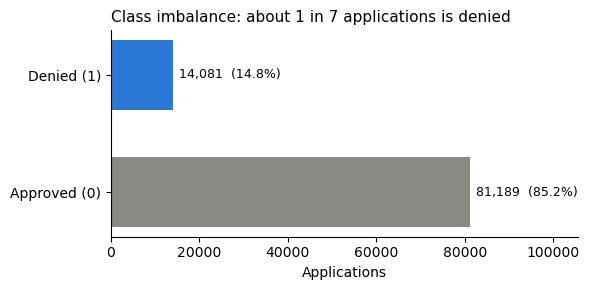

In [80]:
# Summary statistics for the numeric features (after cleaning)
num_summary_cols = ["dti", "ltv_calc", "income", "loan_amount", "property_value", "loan_term"]
summary_stats = df_clean[num_summary_cols].describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]]
display(summary_stats.round(1))

# Target distribution: how imbalanced is the outcome?
counts = df_clean["denied"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.barh(["Approved (0)", "Denied (1)"], counts.values, color=["#8a8984", "#2a78d6"], height=0.6)
ax.bar_label(bars, labels=[f"{n:,}  ({n / counts.sum():.1%})" for n in counts.values], padding=4, fontsize=9)
ax.set_xlim(0, counts.max() * 1.3)
ax.set_title("Class imbalance: about 1 in 7 applications is denied", loc="left", fontsize=11)
ax.set_xlabel("Applications")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

**What the summary statistics show:**
- **Class imbalance:** 14,081 denied vs. 81,189 approved (14.8% denied). This is why later sections use recall, precision, F1, and PR-AUC instead of accuracy, and why both models use `class_weight="balanced"`.
- **Skewed money columns:** income, loan amount, and property value all have means well above their medians (for example, median income of 109 vs. a mean of 155, in thousands of dollars), with a few very large values. Tree models aren't affected by this, and the logistic regression scales these columns.
- **Loan term** is almost always 360 months (the median and 75th percentile are both 360), so unusual terms stand out. That's why the 300-month spike is checked below.

In [48]:
overall_rate = df_clean["denied"].mean()

cat_labels = {
    "preapproval": {1: "Requested", 2: "Not requested"},
    "construction_method": {1: "Site-built", 2: "Manufactured"},
    "applicant_age": {"8888": "N/A"},
}
age_order = ["<25", "25-34", "35-44", "45-54", "55-64", "65-74", ">74", "N/A"]

def denial_summary(groups, name):
    """Denial rate and application count per group, as a tidy table."""
    out = (df_clean.groupby(groups, observed=True)["denied"]
           .agg(denial_rate="mean", applications="count")
           .reset_index())
    out.columns = ["group", "denial_rate", "applications"]
    out.insert(0, "variable", name)
    out["vs_overall"] = out["denial_rate"] - overall_rate
    return out

cat_tables = {}
for col in ["preapproval", "construction_method", "applicant_age"]:
    groups = df_clean[col].astype(str).str.replace(r"\.0$", "", regex=True)
    labels = {str(k): v for k, v in cat_labels.get(col, {}).items()}
    t = denial_summary(groups.replace(labels), col)
    if col == "applicant_age":
        t = t.set_index("group").reindex([a for a in age_order if a in set(t["group"])]).reset_index()
    cat_tables[col] = t

cat_summary = pd.concat(cat_tables.values(), ignore_index=True)

print(f"Overall denial rate: {overall_rate:.1%}")
display(cat_summary.set_index(["variable", "group"]).style
        .format({"denial_rate": "{:.1%}", "applications": "{:,}", "vs_overall": "{:+.1%}"})
        .background_gradient(subset="denial_rate", cmap="Blues"))


Overall denial rate: 14.8%


### Numeric features (split into deciles)

In [49]:
num_check = ["dti", "ltv_calc", "income", "loan_amount", "property_value", "loan_term"]

def short_num(x):
    """1234567 -> 1.23M, 45000 -> 45K, 36.5 -> 36.5"""
    for div, suffix in [(1e6, "M"), (1e3, "K")]:
        if abs(x) >= div:
            return f"{x / div:.3g}{suffix}"
    return f"{x:.3g}"

num_tables = {}
for col in num_check:
    bins = pd.qcut(df_clean[col], q=10, duplicates="drop")
    t = denial_summary(bins, col)
    t["group"] = [f"{short_num(iv.left)}-{short_num(iv.right)}" for iv in t["group"]]
    num_tables[col] = t

num_summary = pd.concat(num_tables.values(), ignore_index=True)
display(num_summary.set_index(["variable", "group"]).style
        .format({"denial_rate": "{:.1%}", "applications": "{:,}", "vs_overall": "{:+.1%}"})
        .background_gradient(subset="denial_rate", cmap="Blues"))


### Most common exact values (catches placeholder values)

In [50]:
spikes = []
for col in num_check:
    counts = df_clean[col].value_counts()
    for v in counts.head(3).index:
        spikes.append({
            "variable": col,
            "value": short_num(v),
            "applications": counts[v],
            "share_of_rows": counts[v] / len(df_clean),
            "denial_rate": df_clean.loc[df_clean[col] == v, "denied"].mean(),
        })

display(pd.DataFrame(spikes).set_index(["variable", "value"]).style
        .format({"applications": "{:,}", "share_of_rows": "{:.1%}", "denial_rate": "{:.1%}"}))


### Denial rate by feature

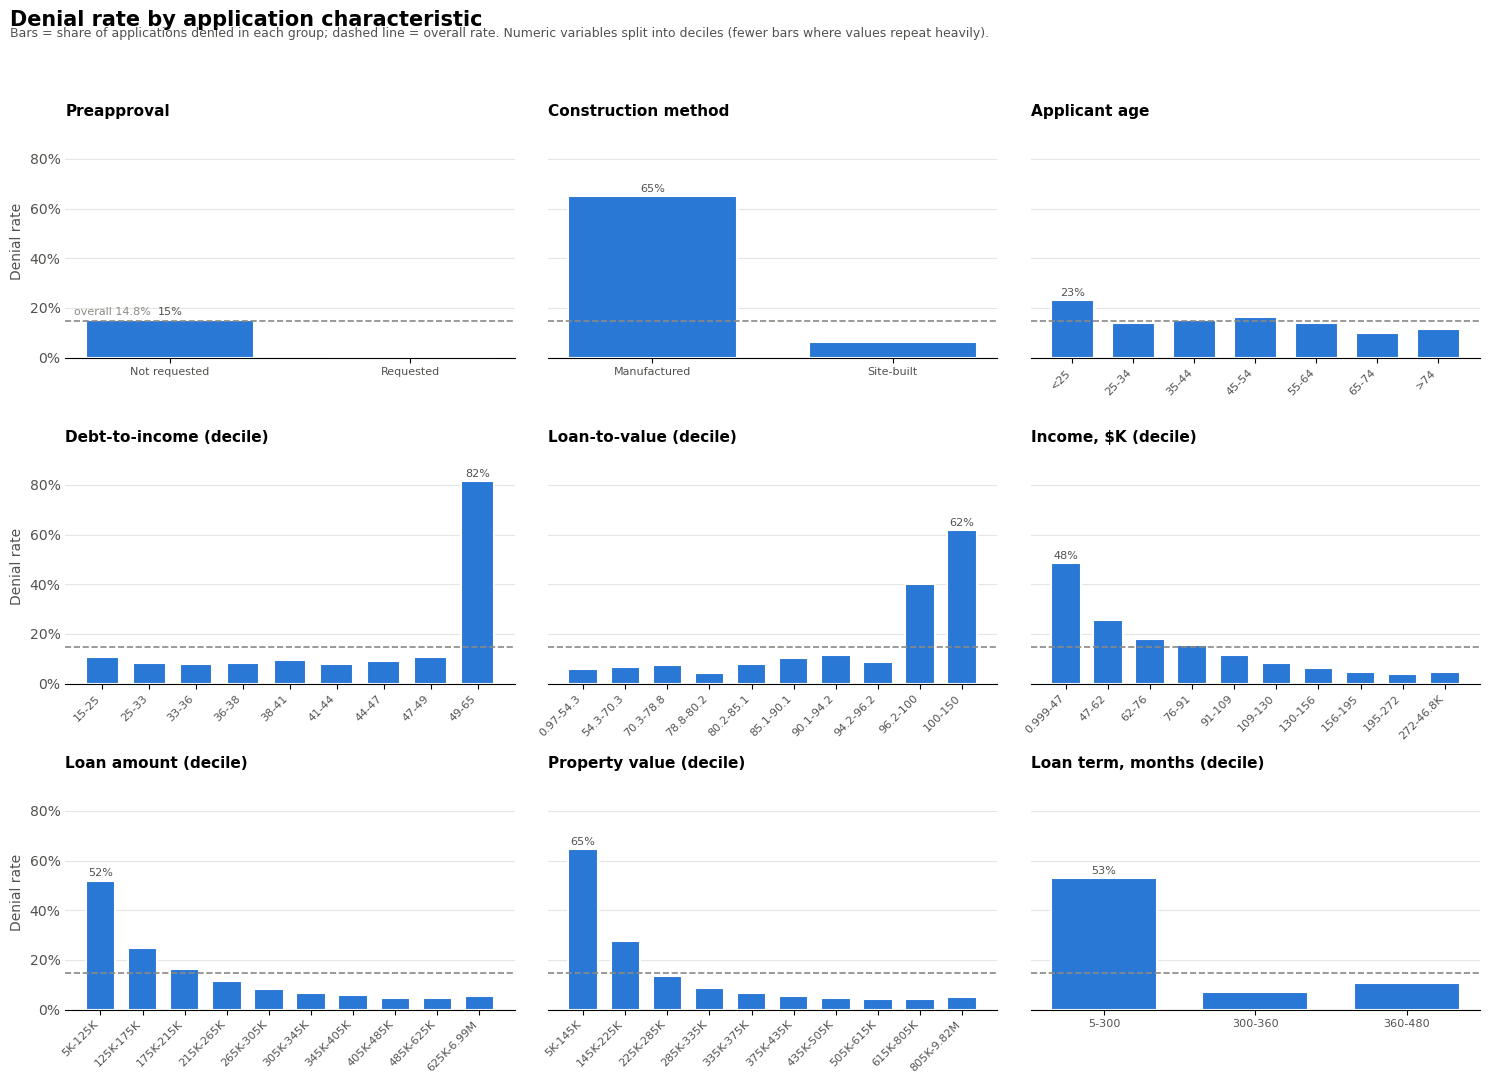

In [51]:
BAR = "#2a78d6"   # one series, one color
REF = "#8a8984"   # overall-rate reference line
INK = "#52514e"

plot_order = list(cat_tables) + num_check
titles = {
    "preapproval": "Preapproval", "construction_method": "Construction method",
    "applicant_age": "Applicant age", "dti": "Debt-to-income (decile)",
    "ltv_calc": "Loan-to-value (decile)", "income": "Income, $K (decile)",
    "loan_amount": "Loan amount (decile)", "property_value": "Property value (decile)",
    "loan_term": "Loan term, months (decile)",
}
all_tables = {**cat_tables, **num_tables}
ymax = max(t["denial_rate"].max() for t in all_tables.values()) * 1.15

fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharey=True)
for ax, col in zip(axes.flat, plot_order):
    t = all_tables[col]
    x = np.arange(len(t))
    ax.bar(x, t["denial_rate"], color=BAR, width=0.7, edgecolor="white", linewidth=1.5)
    ax.axhline(overall_rate, color=REF, linestyle="--", linewidth=1.2)
    ax.set_xticks(x, t["group"], rotation=45 if len(t) > 3 else 0,
                  ha="right" if len(t) > 3 else "center", fontsize=8, color=INK)
    ax.set_title(titles[col], loc="left", fontsize=11, fontweight="bold")
    ax.set_ylim(0, ymax)
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1, decimals=0))
    ax.grid(axis="y", color="#e6e5e0", linewidth=0.8)
    ax.set_axisbelow(True)
    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)
    ax.tick_params(axis="y", length=0, colors=INK)
    # label only the highest bar in each panel
    i = t["denial_rate"].idxmax()
    ax.annotate(f"{t.loc[i, 'denial_rate']:.0%}", (x[i], t.loc[i, "denial_rate"]),
                xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8, color=INK)

axes[0, 0].annotate(f"overall {overall_rate:.1%}", (-0.4, overall_rate), xytext=(0, 4),
                    textcoords="offset points", fontsize=8, color=REF)
for ax in axes[:, 0]:
    ax.set_ylabel("Denial rate", color=INK)

fig.suptitle("Denial rate by application characteristic", x=0.01, ha="left",
             fontsize=15, fontweight="bold")
fig.text(0.01, 0.955, "Bars = share of applications denied in each group; dashed line = overall rate. "
         "Numeric variables split into deciles (fewer bars where values repeat heavily).",
         fontsize=9, color=INK)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


### What the leakage check found
| Flag | What the data shows | Decision |
|---|---|---|
| `preapproval = 1` | **0% denied** | **Leak, removed.** Denied preapproval requests are coded `action_taken = 7`, which was excluded when defining the target, so every remaining preapproval application is an approval by construction. |
| `dti` top decile | Flat at about 8–10%, then **82%** above ~50% | **Legitimate.** 50% is the conventional DTI limit, so this is a real underwriting cutoff. |
| `ltv_calc` near 100% | Flat until ~96%, then 40–62% | **Kept, but flagged.** Many rows sit at exactly 100% LTV with a much higher denial rate, likely a placeholder when no appraisal was done. |
| `construction_method` | Manufactured **65%** vs. site-built about 6% | **Real pattern.** The largest single gap in the data. |
| `loan_term = 300` | The most common non-standard term, with a very high denial rate | **Not a leak, but a proxy.** These are almost all manufactured-home loans, concentrated in a few lenders (checked below). |
| Low `income`, `loan_amount`, `property_value` | Roughly 48–65% denied in the bottom decile | **Legitimate, but overlapping.** All point to lower-cost homes, many of them manufactured. |

**Takeaway:** denial risk is concentrated in two places: applications that cross underwriting limits (DTI ≥ 50%, LTV near 100%), and the lower-cost, largely manufactured-home segment, where denial rates exceed 50%. Several features describe that same segment, so they should not be read as separate effects.

In [52]:
# Checking the loan_term = 300 spike
term_300 = df_clean[df_clean["loan_term"] == 300]

print(f"Loans with a 300-month term: {len(term_300):,}")
print(f"Denial rate: {term_300['denied'].mean():.1%}")
print(f"Share that are manufactured homes: {(term_300['construction_method'] == 2).mean():.1%}")
print(f"Different lenders: {term_300['lei'].nunique()}")
print(f"Share from the top 3 lenders: {term_300['lei'].value_counts().head(3).sum() / len(term_300):.1%}")

Loans with a 300-month term: 8,996
Denial rate: 74.3%
Share that are manufactured homes: 97.9%
Different lenders: 47
Share from the top 3 lenders: 94.9%


## Summary: Filtering, Cleaning & Leakage Checks

This section turns the raw 2025 North Carolina HMDA file into a modeling-ready dataset. Every decision was checked against one question: **would this information be available *before* the lender made its decision?** Anything created by the decision itself would leak the answer into the model.

### 1. Defining the Population
The raw file contains **552,230 applications and 99 columns**. I filtered it to match the research question:

| Filter | Kept | Reason |
|---|---|---|
| `action_taken` | 1, 2, 3 | Only applications that reached a lender decision (approved or denied) |
| `loan_purpose` | 1 (home purchase) | Refinances and home-improvement loans are underwritten differently |
| `occupancy_type` | 1 (owner-occupied) | Investor and second-home loans carry different risk rules |
| `derived_loan_product_type` | Conventional: First Lien | Excludes FHA/VA/USDA programs and subordinate liens (second mortgages, HELOCs) |
| `business_or_commercial_purpose` | 2 (not business) | Business loans follow commercial underwriting |

**Result:** 98,352 applications with a **15.7% denial rate**.

**Target variable:** `denied` = 1 if the application was denied (`action_taken` = 3), 0 if approved (`action_taken` = 1 or 2).

### 2. Missing Data Is Not Random
The missing-data check showed that five features had missing values. `loan_to_value_ratio` was the largest, at 12.6% of rows. Before dropping anything, I checked **whether missingness was related to the outcome**:

- Applications missing LTV were denied **72.8%** of the time, compared with **7.5%** when LTV was present.
- Missing `property_value` and `debt_to_income_ratio` were also tied to denial rates above 50%.

A blanket `dropna()` would have removed only 14.5% of rows, but **61.2% of all denials** (9,432 of 15,415), and the denial rate would have fallen from 15.7% to 7.1%. The model would have trained mostly on easy cases.

**Why this happens:** HMDA only requires LTV when the lender relied on it. Many applications are denied before an appraisal takes place, so a blank LTV is partly a *result* of the denial. Using it, imputing it, or flagging it as missing would leak the outcome.

### 3. Cleaning Steps
| Step | Action | Reason |
|---|---|---|
| Hidden missing codes | Converted `"Exempt"` (31 rows) and `applicant_age = 8888` (11 rows) to missing | HMDA uses these codes in place of blank values, so `isna()` doesn't catch them |
| Type conversion | Converted `property_value`, `loan_term`, and `income` to numeric | These were stored as text because of the codes above |
| Invalid income | Treated income ≤ 0 as missing | Zero or negative income is not usable for underwriting |
| DTI encoding | Created a numeric `dti` column: exact values kept, ranges mapped to representative values (e.g., `"20%-<30%"` → 25, `">60%"` → 65) | HMDA mixes ranges and exact percentages in one column. The mapped values for ranges are an approximation. |
| LTV replacement | Dropped reported `loan_to_value_ratio` and computed `ltv_calc = loan_amount / property_value × 100` | Keeps the LTV information without the leaky missingness |
| Remaining missing rows | Dropped rows missing `income`, `property_value`, `dti`, `loan_term`, or `applicant_age` | A small share of rows. This missingness is also not random, so it is listed as a limitation below. |
| Extreme LTV | Capped `ltv_calc` at 150% | Values above 150% are likely property-value errors. They were capped instead of dropped because most of them were denials (see the cleaning output). |

### 4. Columns Not Used as Model Features
| Column(s) | Reason |
|---|---|
| `interest_rate` | Missing for 100% of denied applications, so it reveals the outcome directly |
| `loan_to_value_ratio`, `debt_to_income_ratio` | Replaced by `ltv_calc` and `dti` |
| `action_taken` | Source of the target |
| `loan_purpose`, `occupancy_type`, `derived_loan_product_type`, `business_or_commercial_purpose` | Only one value remains after filtering |
| `lei` | Lender ID. The model would learn which lenders deny rather than which applications are risky. |
| `derived_dwelling_category` | Exact duplicate of `construction_method` in this population (checked in Part 4) |
| `preapproval` | Every preapproval application in the data was approved (0% denial rate), because denied preapprovals are coded `action_taken = 7` and were excluded in Part 1. It reflects the filter, not a real pattern. |

### 5. Final Dataset
- **95,270 applications** (3,082 dropped during cleaning)
- **Denial rate: 14.8%** (from 15.7% after filtering)
- **Model features (8):** `dti`, `ltv_calc`, `income`, `loan_amount`, `property_value`, `loan_term`, `construction_method`, `applicant_age`
- **Audit-only columns:** `applicant_race-1`, `applicant_ethnicity-1`, `applicant_sex`. These are kept alongside the data but **never used as model inputs**. They are used only to compare model errors across groups (Sub-question 2).

### Limitations Introduced Here
- The dropped rows had higher-than-average denial rates, so the final sample slightly under-represents harder-to-classify applications.
- DTI values for the open-ended ranges (`<20%`, `>60%`) are approximations.
- Excluding withdrawn and incomplete applications means the model only covers applicants who reached a final decision.

# Part 4: Final Modeling Dataset

In [53]:
# Final feature list (preapproval removed after the leakage check)
feature_cols = ["dti", "ltv_calc", "income", "loan_amount", "property_value",
                "loan_term", "construction_method", "applicant_age"]

# Audit-only columns: never used as model inputs, only to check errors by group
audit_cols = ["applicant_race-1", "applicant_ethnicity-1", "applicant_sex"]

X = df_clean[feature_cols]
y = df_clean["denied"]
audit = df_clean[audit_cols]

print("X:", X.shape, "| y:", y.shape, "| audit:", audit.shape)
print("Denial rate:", round(y.mean(), 3))

X: (95270, 8) | y: (95270,) | audit: (95270, 3)
Denial rate: 0.148


# Part 5: Baseline Model

Before training models, I set a one-rule baseline: **predict "denied" whenever DTI is 50% or higher.** I chose 50% because it is the standard debt-to-income limit for conventional loans. The goal is for future models to outperform this simple DTI rule based model, if it can't do that, then it is not worth keeping.

Because only about 15% of applications are denied, **accuracy is misleading**: predicting "approved" for everyone is about 85% accurate. I focus on **recall** (what share of real denials are caught), **precision** (when it predicts denial, how often it's right), **F1-score** (a single score that balances recall and precision, and is low if either one is low), and **ROC-AUC / PR-AUC** (how well it ranks applications by risk).

In [54]:
# Importing Machine Learning tools
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, average_precision_score

**Train/test strategy:** 80% of applications are used for training and 20% are held out as a test set that no model sees until final evaluation. The split is stratified on `denied`, so both sets keep the same 14.8% denial rate. A random split fits because all data comes from a single year.

In [55]:
# The audit columns are split at the same time so their rows line up with X_test.
X_train, X_test, y_train, y_test, audit_train, audit_test = train_test_split(
    X, y, audit, test_size=0.2, stratify=y, random_state=42)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Denial rate - train:", round(y_train.mean(), 3), "| test:", round(y_test.mean(), 3))

Train: (76216, 8) | Test: (19054, 8)
Denial rate - train: 0.148 | test: 0.148


In [56]:
rule_pred = (X_test["dti"] >= 50).astype(int)   # yes/no prediction
rule_score = X_test["dti"]                      # DTI itself as a risk score, for ROC-AUC / PR-AUC

print("Recall:   ", round(recall_score(y_test, rule_pred), 3))
print("Precision:", round(precision_score(y_test, rule_pred), 3))
print("F1:       ", round(f1_score(y_test, rule_pred), 3))
print("ROC-AUC:  ", round(roc_auc_score(y_test, rule_score), 3))
print("PR-AUC:   ", round(average_precision_score(y_test, rule_score), 3))

Recall:    0.403
Precision: 0.815
F1:        0.54
ROC-AUC:   0.694
PR-AUC:    0.493


### Baseline results
| Baseline | Recall | Precision | F1 | ROC-AUC | PR-AUC |
|---|---|---|---|---|---|
| DTI ≥ 50% rule | 0.403 | 0.815 | 0.540 | 0.694 | 0.493 |

The rule is precise: when it predicts a denial, it's right 81.5% of the time. But it catches only **40% of denials**. The other 60% were denied for reasons a DTI cutoff can't see. The models need to raise recall and ROC-AUC above this baseline without giving up too much precision.

# Part 6: Model 1 – Logistic Regression

Logistic regression is the standard starting model for credit decisions. It is fast and easy to interpret, and it gives a probability of denial for each application rather than just a yes/no answer.

Setup choices:
- **Numeric features are scaled** (`StandardScaler`) so features measured in dollars don't outweigh features measured in percent.
- **Categorical features are one-hot encoded** (`construction_method`, `applicant_age`).
- **`class_weight="balanced"`** makes the model pay more attention to the smaller "denied" class. Without it, the model could reach about 85% accuracy by predicting "approved" for everyone.
- Scaling and encoding are inside a **pipeline**, so they are learned from the training data only and never see the test set.
- Other hyperparameters were left at their defaults.

In [57]:
# Importing Machine Learning tools

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [58]:
num_cols = ["dti", "ltv_calc", "income", "loan_amount", "property_value", "loan_term"]
cat_cols = ["construction_method", "applicant_age"]

# Scale the numeric columns, one-hot encode the categorical ones
preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

logreg = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(class_weight="balanced", max_iter=2000)),
])

In [59]:
# Train and score the model 5 times on different slices of the training data
cv_scores = cross_val_score(logreg, X_train, y_train, cv=5, scoring="roc_auc")

print("ROC-AUC per fold:", cv_scores.round(3))
print("Average ROC-AUC: ", round(cv_scores.mean(), 3))

ROC-AUC per fold: [0.878 0.886 0.878 0.883 0.875]
Average ROC-AUC:  0.88


In [60]:
logreg.fit(X_train, y_train)

lr_pred = logreg.predict(X_test)                # 0 or 1
lr_proba = logreg.predict_proba(X_test)[:, 1]   # probability of denial

print("Recall:   ", round(recall_score(y_test, lr_pred), 3))
print("Precision:", round(precision_score(y_test, lr_pred), 3))
print("F1:       ", round(f1_score(y_test, lr_pred), 3))
print("ROC-AUC:  ", round(roc_auc_score(y_test, lr_proba), 3))
print("PR-AUC:   ", round(average_precision_score(y_test, lr_proba), 3))
print()
print(classification_report(y_test, lr_pred, target_names=["Approved", "Denied"]))

Recall:    0.766
Precision: 0.645
F1:        0.7
ROC-AUC:   0.878
PR-AUC:    0.704

              precision    recall  f1-score   support

    Approved       0.96      0.93      0.94     16238
      Denied       0.64      0.77      0.70      2816

    accuracy                           0.90     19054
   macro avg       0.80      0.85      0.82     19054
weighted avg       0.91      0.90      0.91     19054



In [61]:
log_cm = pd.DataFrame(confusion_matrix(y_test, lr_pred),
                  index=["Actually approved", "Actually denied"],
                  columns=["Predicted approved", "Predicted denied"])
log_cm

,Predicted approved,Predicted denied
Actually approved,15049,1189
Actually denied,659,2157


In [62]:
results = pd.DataFrame({
    "Recall":    [recall_score(y_test, rule_pred), recall_score(y_test, lr_pred)],
    "Precision": [precision_score(y_test, rule_pred), precision_score(y_test, lr_pred)],
    "F1":        [f1_score(y_test, rule_pred), f1_score(y_test, lr_pred)],
    "ROC-AUC":   [roc_auc_score(y_test, rule_score), roc_auc_score(y_test, lr_proba)],
    "PR-AUC":    [average_precision_score(y_test, rule_score), average_precision_score(y_test, lr_proba)],
}, index=["Baseline: DTI >= 50%", "Logistic Regression"]).round(3)

results

,Recall,Precision,F1,ROC-AUC,PR-AUC
Baseline: DTI >= 50%,0.403,0.815,0.54,0.694,0.493
Logistic Regression,0.766,0.645,0.70,0.878,0.704


### Logistic regression results
The model clearly beats the baseline. It catches **77% of denials vs. 40%** for the DTI rule, and ROC-AUC rises from **0.694 to 0.878**. The tradeoff is precision: when the model predicts a denial, it's right 64.5% of the time, compared with 81.5% for the rule. F1, which balances the two, rises from **0.540 to 0.700**. Overall, the gain in recall outweighs the loss in precision. In other words, the model flags many more risky applications, at the cost of more false positives (1,189 approved applications flagged as denials).

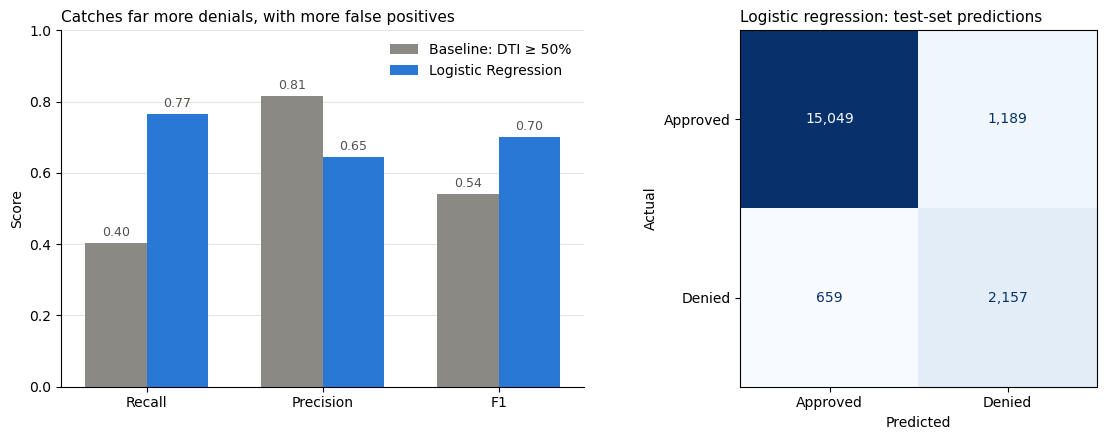

In [63]:
from sklearn.metrics import ConfusionMatrixDisplay

GRAY = "#8a8984"    # baseline
BLUE = "#2a78d6"    # logistic regression
ORANGE = "#eb6834"  # gradient boosting
INK = "#52514e"

def clean_axes(ax):
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    ax.grid(axis="y", color="#e6e5e0", linewidth=0.8)
    ax.set_axisbelow(True)

# Baseline vs. logistic regression on the two yes/no metrics
metrics = ["Recall", "Precision", "F1"]
base_vals = [results.loc["Baseline: DTI >= 50%", m] for m in metrics]
lr_vals = [results.loc["Logistic Regression", m] for m in metrics]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

x = np.arange(len(metrics))
w = 0.35
b1 = ax1.bar(x - w/2, base_vals, w, color=GRAY, label="Baseline: DTI ≥ 50%")
b2 = ax1.bar(x + w/2, lr_vals, w, color=BLUE, label="Logistic Regression")
ax1.bar_label(b1, fmt="%.2f", padding=3, fontsize=9, color=INK)
ax1.bar_label(b2, fmt="%.2f", padding=3, fontsize=9, color=INK)
ax1.set_xticks(x, metrics)
ax1.set_ylim(0, 1)
ax1.set_ylabel("Score")
ax1.set_title("Catches far more denials, with more false positives", loc="left", fontsize=11)
ax1.legend(frameon=False, loc="upper right")
clean_axes(ax1)

# Confusion matrix for logistic regression
ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred, display_labels=["Approved", "Denied"],
    cmap="Blues", colorbar=False, values_format=",", ax=ax2)
ax2.set_title("Logistic regression: test-set predictions", loc="left", fontsize=11)
ax2.set_xlabel("Predicted")
ax2.set_ylabel("Actual")

plt.tight_layout()
plt.show()

# Part 7: Model 2 – Gradient Boosting

Gradient boosting builds many small decision trees, with each tree correcting the mistakes of the ones before it. Unlike logistic regression, it can capture:
- **Cutoffs**, like the jump in denials at DTI ≈ 50%, which a straight-line model can only approximate
- **Interactions**, like high DTI *combined with* a manufactured home

I use `HistGradientBoostingClassifier`, scikit-learn's fast version for large datasets.

Setup choices:
- **No scaling.** Tree models split on thresholds, so feature scale doesn't matter.
- **`class_weight="balanced"`**, same as Model 1, so the comparison is fair.
- **Same train/test split and the same 5-fold cross-validation** as Model 1.
- **Hyperparameter tuning:** I tested 6 combinations of learning rate and tree depth using cross-validation on the training data only. The test set was not used to choose settings.

In [64]:
# Importing Machine Learning tools

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import HistGradientBoostingClassifier

In [65]:

preprocess_hgb = ColumnTransformer([
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

hgb = Pipeline([
    ("preprocess", preprocess_hgb),
    ("model", HistGradientBoostingClassifier(class_weight="balanced", random_state=42)),
])

In [66]:
# Try every combination below, scoring each with 5-fold CV on the training data
param_grid = {
    "model__learning_rate": [0.05, 0.1],   # how big each correction step is
    "model__max_depth": [3, 6, None],      # how deep each tree can grow (None = no limit)
}

grid = GridSearchCV(hgb, param_grid, cv=5, scoring="roc_auc")
grid.fit(X_train, y_train)

print("Best settings:", grid.best_params_)
print("Best CV ROC-AUC:", round(grid.best_score_, 3))

# All results, to show how much the settings mattered
pd.DataFrame(grid.cv_results_)[["param_model__learning_rate", "param_model__max_depth",
                                "mean_test_score"]].round(3)

Best settings: {'model__learning_rate': 0.05, 'model__max_depth': 6}
Best CV ROC-AUC: 0.917


,param_model__learning_rate,param_model__max_depth,mean_test_score
0,0.05,3,0.914
1,0.05,6,0.917
2,0.05,None,0.917
3,0.10,3,0.916
4,0.10,6,0.916
5,0.10,None,0.916


In [67]:
hgb_best = grid.best_estimator_

hgb_pred = hgb_best.predict(X_test)
hgb_proba = hgb_best.predict_proba(X_test)[:, 1]

print("Recall:   ", round(recall_score(y_test, hgb_pred), 3))
print("Precision:", round(precision_score(y_test, hgb_pred), 3))
print("F1:       ", round(f1_score(y_test, hgb_pred), 3))
print("ROC-AUC:  ", round(roc_auc_score(y_test, hgb_proba), 3))
print("PR-AUC:   ", round(average_precision_score(y_test, hgb_proba), 3))
print()
print(classification_report(y_test, hgb_pred, target_names=["Approved", "Denied"]))

Recall:    0.809
Precision: 0.679
F1:        0.738
ROC-AUC:   0.918
PR-AUC:    0.802

              precision    recall  f1-score   support

    Approved       0.97      0.93      0.95     16238
      Denied       0.68      0.81      0.74      2816

    accuracy                           0.92     19054
   macro avg       0.82      0.87      0.84     19054
weighted avg       0.92      0.92      0.92     19054



In [68]:
hgb_cm = pd.DataFrame(confusion_matrix(y_test, hgb_pred),
                      index=["Actually approved", "Actually denied"],
                      columns=["Predicted approved", "Predicted denied"])
hgb_cm

,Predicted approved,Predicted denied
Actually approved,15159,1079
Actually denied,538,2278


In [69]:
results.loc["Gradient Boosting"] = [
    recall_score(y_test, hgb_pred),
    precision_score(y_test, hgb_pred),
    f1_score(y_test, hgb_pred),
    roc_auc_score(y_test, hgb_proba),
    average_precision_score(y_test, hgb_proba),
]
results.round(3)

,Recall,Precision,F1,ROC-AUC,PR-AUC
Baseline: DTI >= 50%,0.403,0.815,0.540,0.694,0.493
Logistic Regression,0.766,0.645,0.700,0.878,0.704
Gradient Boosting,0.809,0.679,0.738,0.918,0.802


In [70]:
# Earlier, many rows had LTV of exactly 100% with an unusually high denial rate (a possible placeholder).
# Retrain without ltv_calc: if performance barely changes, the model isn't relying on that pattern.
num_no_ltv = [c for c in num_cols if c != "ltv_calc"]

hgb_no_ltv = Pipeline([
    ("preprocess", ColumnTransformer([
        ("num", "passthrough", num_no_ltv),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ])),
    ("model", HistGradientBoostingClassifier(class_weight="balanced", random_state=42,
                                             learning_rate=grid.best_params_["model__learning_rate"],
                                             max_depth=grid.best_params_["model__max_depth"])),
])
hgb_no_ltv.fit(X_train, y_train)
no_ltv_proba = hgb_no_ltv.predict_proba(X_test)[:, 1]

print("ROC-AUC with LTV:   ", round(roc_auc_score(y_test, hgb_proba), 3))
print("ROC-AUC without LTV:", round(roc_auc_score(y_test, no_ltv_proba), 3))
print("PR-AUC with LTV:    ", round(average_precision_score(y_test, hgb_proba), 3))
print("PR-AUC without LTV: ", round(average_precision_score(y_test, no_ltv_proba), 3))

ROC-AUC with LTV:    0.918
ROC-AUC without LTV: 0.912
PR-AUC with LTV:     0.802
PR-AUC without LTV:  0.789


### Gradient boosting results
Gradient boosting beats logistic regression on **every metric**. The biggest gain is in PR-AUC (**0.704 -> 0.802**), the stricter metric for this imbalanced target. F1 also improves (**0.700 -> 0.738**). It catches more denials (81% vs. 77%) **and** has fewer false positives (1,079 vs. 1,189), so the gain isn't simply a tradeoff of one for the other.

**Why it performs better:** the leakage check showed that denial risk jumps at cutoffs (DTI near 50%, LTV near 100%) and clusters in the manufactured-home segment. Trees capture cutoffs and interactions directly, while logistic regression can only fit one smooth trend per feature.

**Tuning made little difference:** all six settings scored between 0.914 and 0.917 in cross-validation. The gain over logistic regression comes from the type of model, not from fine-tuning.

**LTV check:** removing `ltv_calc` lowers ROC-AUC only from 0.918 to 0.912. The model is **not** depending on the suspicious "LTV = exactly 100%" pattern found earlier, so the results hold up without it.

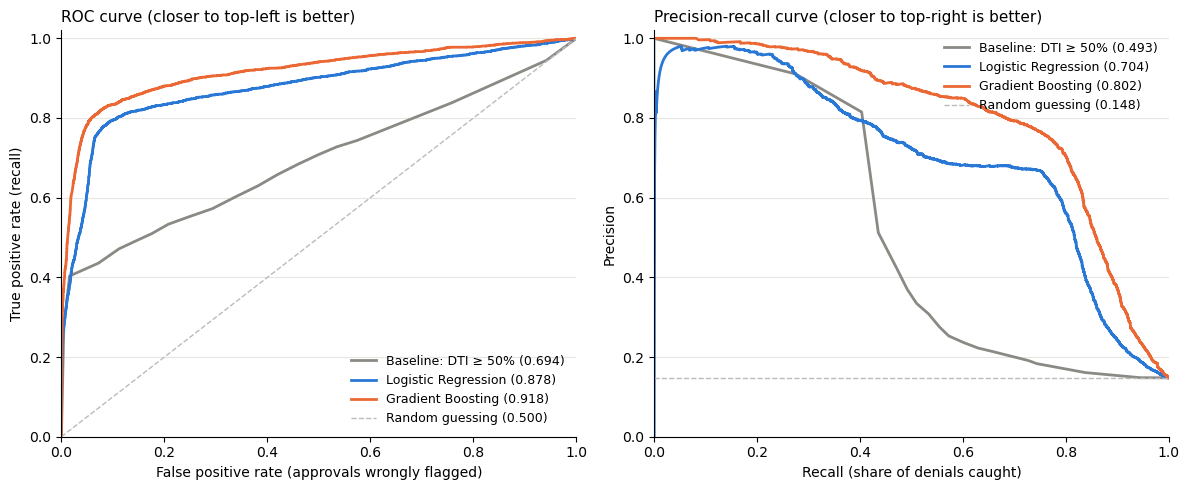

In [71]:
from sklearn.metrics import roc_curve, precision_recall_curve

models = {
    "Baseline: DTI ≥ 50%": (rule_score, GRAY),
    "Logistic Regression": (lr_proba, BLUE),
    "Gradient Boosting": (hgb_proba, ORANGE),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for name, (score, color) in models.items():
    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, score)
    auc = roc_auc_score(y_test, score)
    ax1.plot(fpr, tpr, color=color, lw=2, label=f"{name} ({auc:.3f})")
    # Precision-recall curve
    prec, rec, _ = precision_recall_curve(y_test, score)
    ap = average_precision_score(y_test, score)
    ax2.plot(rec, prec, color=color, lw=2, label=f"{name} ({ap:.3f})")

# Reference lines: what random guessing would score
ax1.plot([0, 1], [0, 1], color="#bbbbbb", ls="--", lw=1, label="Random guessing (0.500)")
ax2.axhline(y_test.mean(), color="#bbbbbb", ls="--", lw=1,
            label=f"Random guessing ({y_test.mean():.3f})")

ax1.set_title("ROC curve (closer to top-left is better)", loc="left", fontsize=11)
ax1.set_xlabel("False positive rate (approvals wrongly flagged)")
ax1.set_ylabel("True positive rate (recall)")
ax2.set_title("Precision-recall curve (closer to top-right is better)", loc="left", fontsize=11)
ax2.set_xlabel("Recall (share of denials caught)")
ax2.set_ylabel("Precision")

for ax in (ax1, ax2):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.legend(frameon=False, loc="lower right" if ax is ax1 else "upper right", fontsize=9)
    clean_axes(ax)

plt.tight_layout()
plt.show()

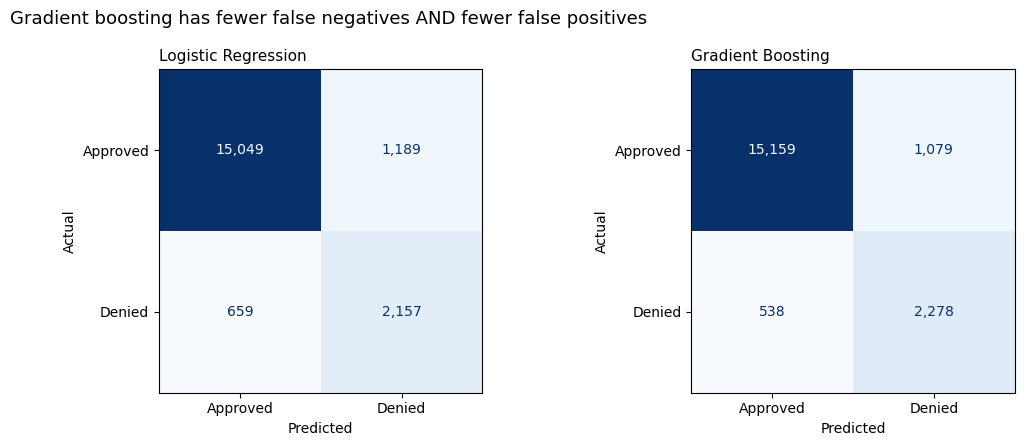

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (name, pred) in zip(axes, [("Logistic Regression", lr_pred), ("Gradient Boosting", hgb_pred)]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred, display_labels=["Approved", "Denied"],
        cmap="Blues", colorbar=False, values_format=",", ax=ax)
    ax.set_title(name, loc="left", fontsize=11)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

fig.suptitle("Gradient boosting has fewer false negatives AND fewer false positives",
             x=0.01, ha="left", fontsize=13)
plt.tight_layout()
plt.show()

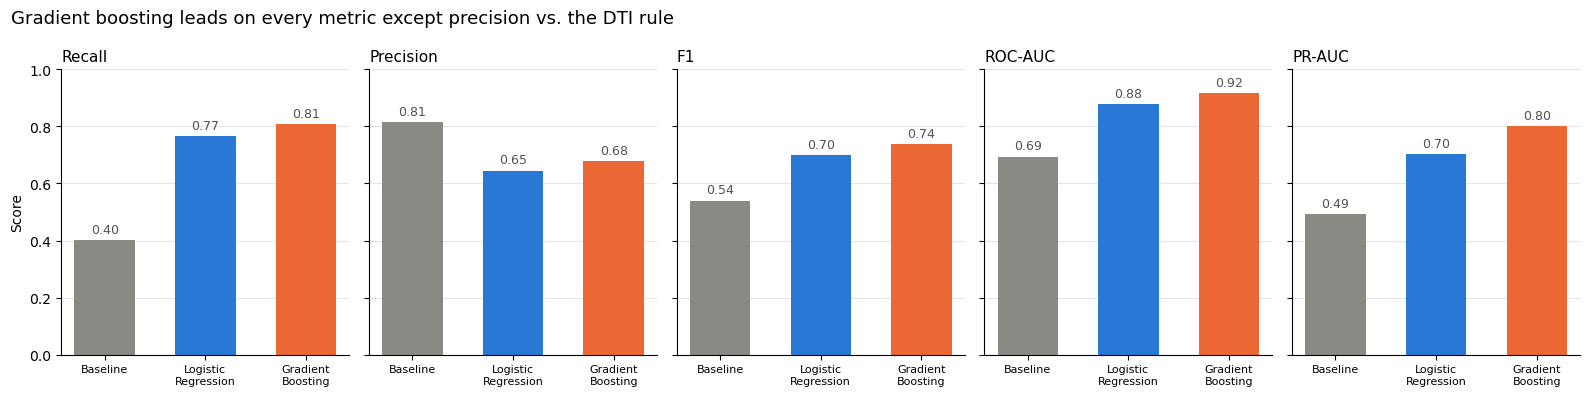

In [73]:
fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharey=True)
colors = [GRAY, BLUE, ORANGE]
labels = ["Baseline", "Logistic\nRegression", "Gradient\nBoosting"]

for ax, metric in zip(axes, results.columns):
    vals = results[metric].values
    bars = ax.bar(labels, vals, color=colors, width=0.6)
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9, color=INK)
    ax.set_title(metric, loc="left", fontsize=11)
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", labelsize=8)
    clean_axes(ax)

axes[0].set_ylabel("Score")
fig.suptitle("Gradient boosting leads on every metric except precision vs. the DTI rule",
             x=0.01, ha="left", fontsize=13)
plt.tight_layout()
plt.show()

# Part 8: Conclusion & Fairness Audit

### Model scorecard

In [74]:
# One point per metric to whichever model scores best
scoreboard = results.copy()
winners = scoreboard.idxmax(axis=0)          # best row for each metric
points = winners.value_counts().reindex(scoreboard.index, fill_value=0)

print("Winner by metric:")
print(winners)
print()
print("Points:")
print(points)

Winner by metric:
Recall          Gradient Boosting
Precision    Baseline: DTI >= 50%
F1              Gradient Boosting
ROC-AUC         Gradient Boosting
PR-AUC          Gradient Boosting
dtype: object

Points:
Baseline: DTI >= 50%    1
Logistic Regression     0
Gradient Boosting       4
Name: count, dtype: int64


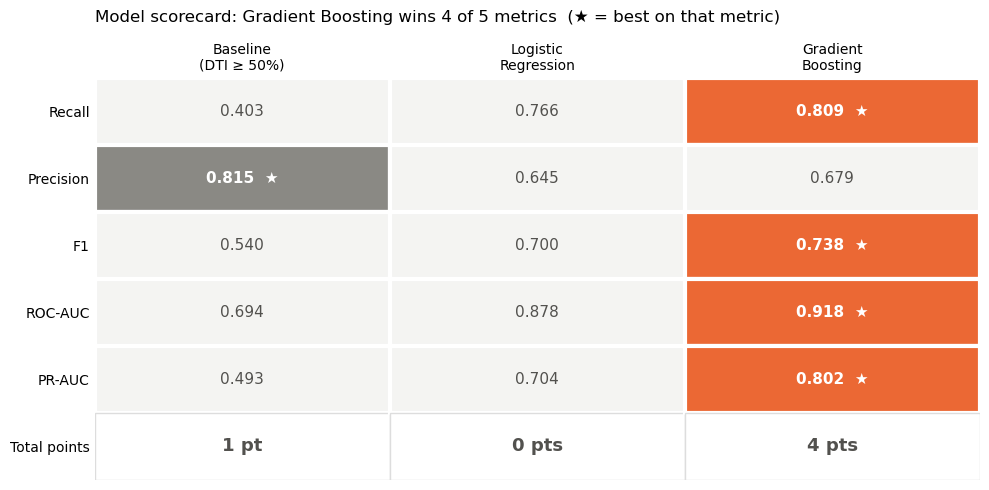

In [75]:
model_colors = {"Baseline: DTI >= 50%": GRAY, "Logistic Regression": BLUE, "Gradient Boosting": ORANGE}
model_labels = ["Baseline\n(DTI ≥ 50%)", "Logistic\nRegression", "Gradient\nBoosting"]
metrics = list(scoreboard.columns)

fig, ax = plt.subplots(figsize=(10, 5))
n_rows, n_cols = len(metrics) + 1, len(scoreboard.index)

for c, model in enumerate(scoreboard.index):
    for r, metric in enumerate(metrics):
        is_winner = winners[metric] == model
        ax.add_patch(plt.Rectangle((c, r), 1, 1,
                     facecolor=model_colors[model] if is_winner else "#f4f4f2",
                     edgecolor="white", linewidth=3))
        ax.text(c + 0.5, r + 0.5, f"{scoreboard.loc[model, metric]:.3f}" + ("  ★" if is_winner else ""),
                ha="center", va="center", fontsize=11,
                color="white" if is_winner else INK, fontweight="bold" if is_winner else "normal")
    # Points row
    ax.add_patch(plt.Rectangle((c, n_rows - 1), 1, 1, facecolor="white", edgecolor="#dddddd"))
    ax.text(c + 0.5, n_rows - 0.5, f"{points[model]} pt" + ("s" if points[model] != 1 else ""),
            ha="center", va="center", fontsize=13, fontweight="bold", color=INK)

ax.set_xlim(0, n_cols)
ax.set_ylim(n_rows, 0)
ax.set_xticks(np.arange(n_cols) + 0.5, model_labels, fontsize=10)
ax.xaxis.tick_top()
ax.set_yticks(np.arange(n_rows) + 0.5, metrics + ["Total points"], fontsize=10)
ax.tick_params(length=0)
for s in ax.spines.values():
    s.set_visible(False)

best = points.idxmax()
ax.set_title(f"Model scorecard: {best} wins {points[best]} of {len(metrics)} metrics  (★ = best on that metric)",
             loc="left", fontsize=12, pad=40)
plt.tight_layout()
plt.show()

## Feature importance

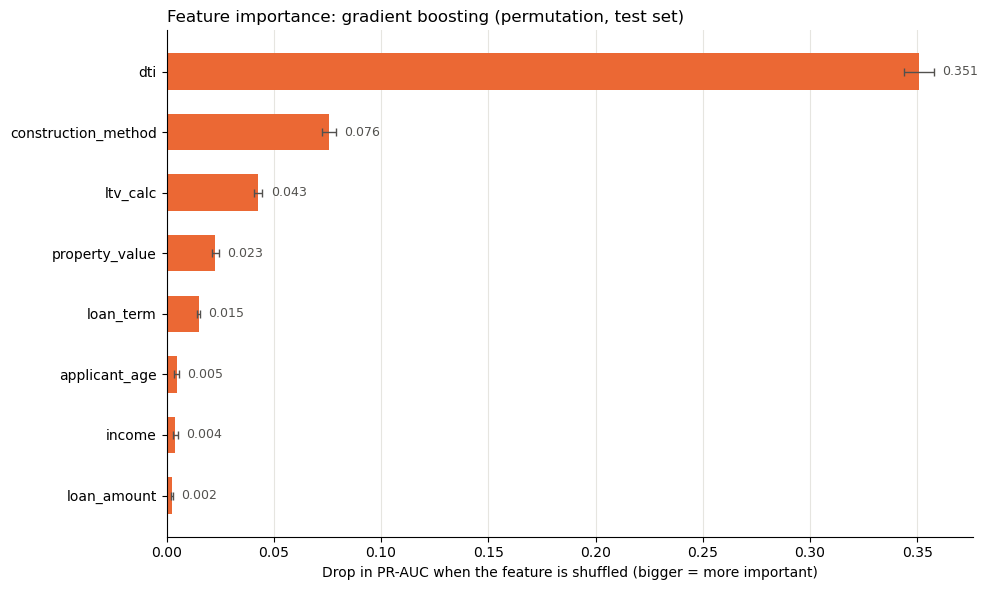

,Feature,PR-AUC drop,Std
0,dti,0.351,0.007
6,construction_method,0.076,0.003
1,ltv_calc,0.043,0.002
4,property_value,0.023,0.002
5,loan_term,0.015,0.001
7,applicant_age,0.005,0.001
2,income,0.004,0.001
3,loan_amount,0.002,0.000


In [76]:
from sklearn.inspection import permutation_importance

# Shuffle one feature at a time on the TEST set and measure how much PR-AUC drops.
# A big drop = the model relies heavily on that feature.
perm = permutation_importance(hgb_best, X_test, y_test, scoring="average_precision",
                              n_repeats=5, random_state=42)

importance = pd.DataFrame({
    "Feature": X_test.columns,
    "PR-AUC drop": perm.importances_mean,
    "Std": perm.importances_std,
}).sort_values("PR-AUC drop")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importance["Feature"], importance["PR-AUC drop"],
               xerr=importance["Std"], color=ORANGE, height=0.6,
               error_kw={"ecolor": INK, "capsize": 3, "lw": 1})
ax.bar_label(bars, fmt="%.3f", padding=6, fontsize=9, color=INK)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
ax.grid(axis="x", color="#e6e5e0", linewidth=0.8)
ax.set_axisbelow(True)
ax.set_xlabel("Drop in PR-AUC when the feature is shuffled (bigger = more important)")
ax.set_title("Feature importance: gradient boosting (permutation, test set)", loc="left", fontsize=12)
plt.tight_layout()
plt.show()

importance.sort_values("PR-AUC drop", ascending=False).round(3)


## Fairness audit

In [77]:
# HMDA codes -> readable group names (sub-codes like 21-27 roll up to their main group)
def race_group(code):
    if pd.isna(code): return "Missing"
    code = int(code)
    if code == 1: return "American Indian / Alaska Native"
    if code == 2 or 21 <= code <= 27: return "Asian"
    if code == 3: return "Black"
    if code == 4 or 41 <= code <= 44: return "Native Hawaiian / Pacific Islander"
    if code == 5: return "White"
    return "Not provided"

def ethnicity_group(code):
    if pd.isna(code): return "Missing"
    code = int(code)
    if code == 1 or 11 <= code <= 14: return "Hispanic or Latino"
    if code == 2: return "Not Hispanic or Latino"
    return "Not provided"

sex_names = {1: "Male", 2: "Female", 3: "Not provided", 4: "Not provided", 6: "Both selected"}

audit_groups = pd.DataFrame({
    "Race": audit_test["applicant_race-1"].apply(race_group),
    "Ethnicity": audit_test["applicant_ethnicity-1"].apply(ethnicity_group),
    "Sex": audit_test["applicant_sex"].map(sex_names),
}, index=audit_test.index)

# Group sizes in the test set (groups under 200 are excluded from the comparison below)
for col in ["Race", "Ethnicity", "Sex"]:
    print(audit_groups[col].value_counts().to_string(), "\n")

Race
White                                 13154
Not provided                           2365
Black                                  1844
Asian                                  1407
American Indian / Alaska Native         257
Native Hawaiian / Pacific Islander       24
Missing                                   3 

Ethnicity
Not Hispanic or Latino    14972
Not provided               2250
Hispanic or Latino         1826
Missing                       6 

Sex
Male             10796
Female            7395
Not provided       846
Both selected       17 



In [78]:
# Error rates by group for the final model (gradient boosting), on the test set only
MIN_ROWS = 200   # groups smaller than this are too noisy to compare

rows = []
for attribute in ["Race", "Ethnicity", "Sex"]:
    for group, idx in audit_groups.groupby(attribute).groups.items():
        actual = y_test.loc[idx]
        pred = pd.Series(hgb_pred, index=y_test.index).loc[idx]
        if len(idx) < MIN_ROWS:
            continue
        tp = ((pred == 1) & (actual == 1)).sum()
        fn = ((pred == 0) & (actual == 1)).sum()
        fp = ((pred == 1) & (actual == 0)).sum()
        tn = ((pred == 0) & (actual == 0)).sum()
        rows.append({
            "Attribute": attribute,
            "Group": group,
            "Applications": len(idx),
            "Actual denial rate": actual.mean(),
            "Predicted denial rate": pred.mean(),
            "Recall (TPR)": tp / (tp + fn),
            "False positive rate": fp / (fp + tn),
            "Precision": tp / (tp + fp),
        })

fairness = pd.DataFrame(rows).set_index(["Attribute", "Group"])
fairness.style.format({
    "Applications": "{:,}", "Actual denial rate": "{:.1%}", "Predicted denial rate": "{:.1%}",
    "Recall (TPR)": "{:.1%}", "False positive rate": "{:.1%}", "Precision": "{:.1%}",
})

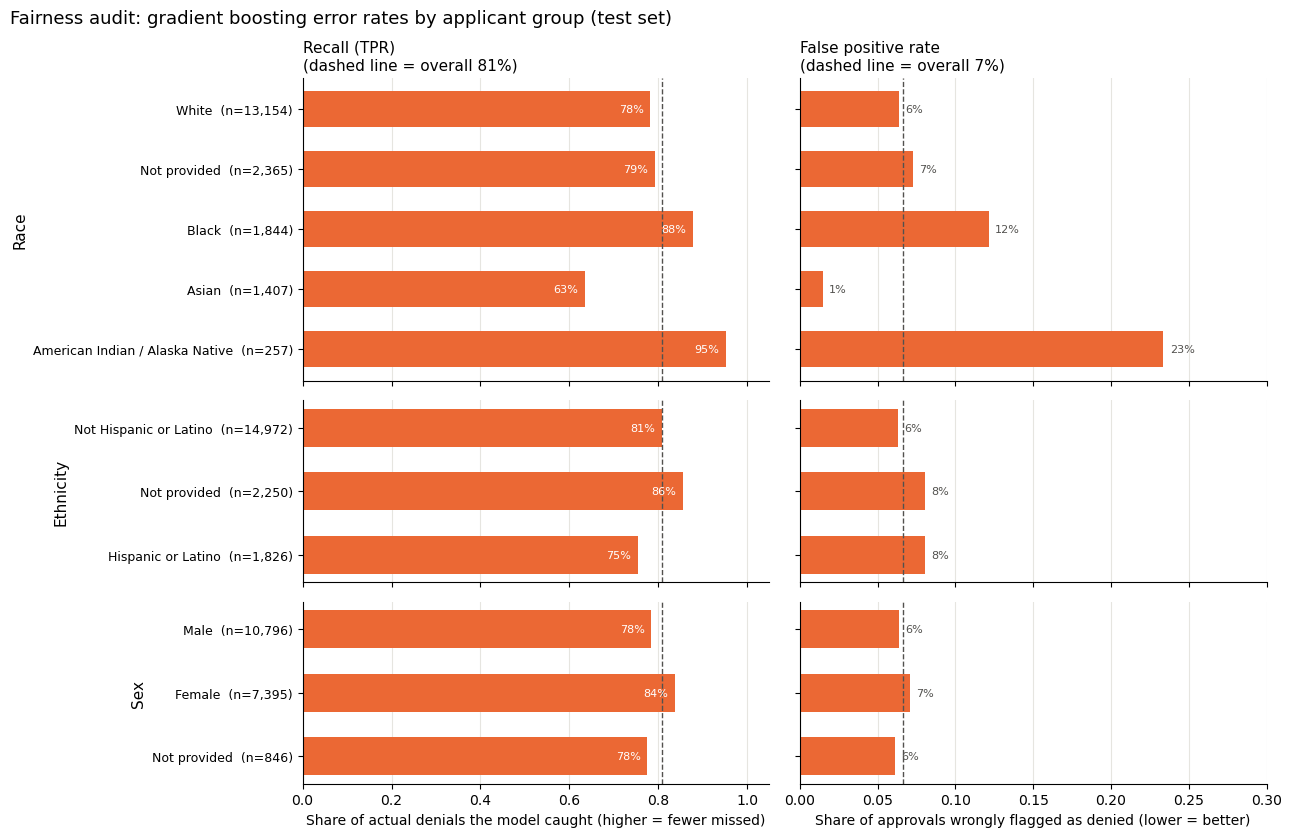

In [79]:
# Overall rates for the reference lines
overall_recall = recall_score(y_test, hgb_pred)
overall_fpr = ((hgb_pred == 1) & (y_test == 0)).sum() / (y_test == 0).sum()

attributes = ["Race", "Ethnicity", "Sex"]
heights = [len(fairness.loc[a]) for a in attributes]

fig, axes = plt.subplots(3, 2, figsize=(13, 8.5), sharex="col",
                         gridspec_kw={"height_ratios": heights})

for r, attribute in enumerate(attributes):
    t = fairness.loc[attribute].sort_values("Applications")
    y_pos = np.arange(len(t))
    for c, (metric, overall, color) in enumerate([
            ("Recall (TPR)", overall_recall, ORANGE),
            ("False positive rate", overall_fpr, ORANGE)]):
        ax = axes[r, c]
        ax.barh(y_pos, t[metric], color=color, height=0.6)
        ax.axvline(overall, color=INK, ls="--", lw=1)
        for yi, v in zip(y_pos, t[metric]):
            if c == 0:   # recall bars are long: label inside the bar end
                ax.text(v - 0.015, yi, f"{v:.0%}", va="center", ha="right", fontsize=8, color="white")
            else:        # FPR bars can be tiny: label just outside
                ax.text(v + 0.004, yi, f"{v:.0%}", va="center", fontsize=8, color=INK)
        ax.set_yticks(y_pos, [f"{g}  (n={n:,})" for g, n in zip(t.index, t["Applications"])]
                      if c == 0 else [""] * len(t), fontsize=9)
        for s in ["top", "right"]:
            ax.spines[s].set_visible(False)
        ax.grid(axis="x", color="#e6e5e0", linewidth=0.8)
        ax.set_axisbelow(True)
        if r == 0:
            ax.set_title(f"{metric}\n(dashed line = overall {overall:.0%})", loc="left", fontsize=11)
    axes[r, 0].set_ylabel(attribute, fontsize=11)

axes[2, 0].set_xlim(0, 1.05)
axes[2, 1].set_xlim(0, 0.3)
axes[2, 0].set_xlabel("Share of actual denials the model caught (higher = fewer missed)")
axes[2, 1].set_xlabel("Share of approvals wrongly flagged as denied (lower = better)")
fig.suptitle("Fairness audit: gradient boosting error rates by applicant group (test set)",
             x=0.01, ha="left", fontsize=13)
plt.tight_layout()
plt.show()

## Final model: Gradient Boosting
Each model earned one point for every metric it scored best on. **Gradient boosting won 4 of 5** (recall, F1, ROC-AUC, PR-AUC). The DTI rule won precision, and logistic regression won none.

The tally is a summary, not the whole argument. Gradient boosting is the final choice because it leads on the two metrics that matter most for this problem:
- **PR-AUC (0.802)**, the strictest measure for an imbalanced target, where random guessing scores only 0.148
- **F1 (0.738)**, which balances catching denials against false positives

The DTI rule's higher precision (0.815) comes from catching only the most obvious cases: it misses 60% of denials. Gradient boosting also improved on logistic regression without a tradeoff, with fewer false negatives (538 vs. 659) **and** fewer false positives (1,079 vs. 1,189).

## Answering the research question
> *How accurately can we predict whether a conventional, owner-occupied home-purchase mortgage application in North Carolina is denied, using only publicly reported HMDA characteristics?*

**Fairly accurately, with limits.** Using only 8 public features and no credit scores, gradient boosting ranks a denied application above an approved one **92% of the time** (ROC-AUC 0.918) and catches **81% of denials**. About 1 in 3 of its denial predictions are still wrong (precision 0.679). That gap is expected: credit history, a major underwriting factor, is not in the public data.

## Which features matter most?
To measure importance, I used **permutation importance** on the test set: shuffle one feature at a time and measure how much PR-AUC drops. If the score falls a lot, the model depends on that feature. Unlike logistic regression coefficients, it works for any model and is measured in PR-AUC, the main metric of this project.

| Rank | Feature | PR-AUC drop |
|---|---|---|
| 1 | Debt-to-income ratio (`dti`) | **0.351** |
| 2 | Construction method (manufactured vs. site-built) | 0.076 |
| 3 | Loan-to-value ratio (`ltv_calc`) | 0.043 |
| 4 | Property value | 0.023 |
| 5 | Loan term | 0.015 |
| 6–8 | Applicant age, income, loan amount | ≤ 0.005 each |

**Debt-to-income ratio dominates.** Shuffling it drops PR-AUC by 0.351, more than four times the next feature. This matches the leakage check, where denial rates jumped from about 10% to 82% once DTI passed ~50%, the conventional loan limit.

**Income and loan amount contribute almost nothing on their own**, even though both showed strong patterns in the earlier charts (low-income applicants were denied 48% of the time). That isn't a contradiction. Income is already part of DTI, and low loan amounts mostly overlap with lower property values and manufactured homes. Once the model has those features, income and loan amount add little new information. Permutation importance tends to understate features that overlap with others, so the honest conclusion is that **income matters mostly *through* DTI**, not that it doesn't matter.

Overall, the predictive signal comes from two places:
1. **Underwriting limits:** DTI above ~50% and, to a lesser degree, LTV near 100%
2. **The lower-cost, mostly manufactured-home segment,** where denial rates exceed 50% and a few lenders account for most of the 300-month loans (Part 3)

## Fairness audit
Race, ethnicity, and sex were **never used as model inputs**. To check whether the model's errors fall evenly anyway, I compared two error rates across groups on the test set:
- **Recall:** of applicants who were actually denied, what share did the model catch?
- **False positive rate:** of applicants who were actually **approved**, what share did the model wrongly flag as denied?

Groups with fewer than 200 test applications were excluded as too small to compare reliably: Native Hawaiian / Pacific Islander (n = 24), applicants who selected both sexes, and rows with missing race or ethnicity.

**Findings:**
- **Approved Black applicants were wrongly flagged as denied at about twice the rate of approved White applicants** (12.2% vs. 6.4%). This is the most important result of the audit: an approved Black applicant was more likely to be labeled high-risk by the model.
- **American Indian / Alaska Native applicants had the highest false positive rate (23.4%)**, but this group is small (n = 257), so the estimate is less certain.
- **Asian applicants had the lowest recall (63.5% vs. 78.2% for White applicants)**: the model missed more of their actual denials.
- **Ethnicity and sex showed smaller gaps.** Female and male applicants had similar false positive rates (7.1% vs. 6.4%), as did Hispanic and non-Hispanic applicants (8.1% vs. 6.3%).

**Why this happens, and what it does and doesn't mean:** actual denial rates differ sharply by group in this data (39.3% for Black applicants vs. 11.3% for White applicants). Even without race as an input, the model can pick up these differences through correlated features such as DTI, property value, and manufactured housing. These features act as **proxies**.

This audit shows that **the model's mistakes are not evenly distributed**. It does **not** show that lenders discriminated, because credit history and other underwriting factors are missing from the data. Anyone using a model like this should check error rates by group before relying on it.

## Consequences of Wrong Predictions
- **False positives (1,079 in the test set):** approved applicants the model labels as likely denials. If a model like this were used to screen or steer applicants, qualified borrowers could be discouraged or denied. The fairness audit shows this error falls more heavily on Black (12.2%) and American Indian / Alaska Native (23.4%) applicants than on White applicants (6.4%), so the harm would not be evenly shared.
- **False negatives (538 in the test set):** actual denials the model misses. For a researcher or regulator, these are denials the model can't explain from public data. They likely depend on factors like credit history that HMDA doesn't publish.

## Should This Model Be Used for Real Decisions?
**No.** It is built to study patterns in public lending data, not to make or recommend lending decisions. It lacks credit scores, it makes more errors for some demographic groups, and its strongest signals (DTI and manufactured housing) partly reflect lender rules and the lenders that dominate certain segments. Anyone using it should treat its outputs as associations, check error rates by group, and never use it to approve or deny real applicants.

## Next Steps
- Test whether the results hold for **site-built homes only**, to measure how much the manufactured-home segment drives performance
- Add **more years** of HMDA data, or other states, to check whether results generalize
- Try **group-specific decision thresholds** to see whether false-positive gaps can be reduced, and what that costs in recall
- Where available, add **credit-related data** to measure how much of the remaining error it explains

## Limitations
- **No credit scores** or full underwriting files, so the model explains only part of each decision
- **Only applications that reached a decision** were included. Withdrawn and incomplete applications were excluded.
- **Dropped rows were not random:** rows removed for missing values had above-average denial rates (the denial rate fell from 15.7% to 14.8% after cleaning).
- **One state and one year** (North Carolina, 2025), so results may not generalize
- **Associations, not causes:** no feature in this model can be read as a cause of denial